In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [74]:
demand = pd.read_csv('../data/processed/demand/demand.csv')

demand.head()

,product_id,m5_item_id,date,demand,week,category
0,P01,FOODS_3_586,2011-01-29,516,1,FOODS
1,P01,FOODS_3_586,2011-01-30,479,1,FOODS
2,P01,FOODS_3_586,2011-01-31,328,1,FOODS
3,P01,FOODS_3_586,2011-02-01,376,1,FOODS
4,P01,FOODS_3_586,2011-02-02,319,1,FOODS


In [75]:
demand.info()

<class 'pandas.DataFrame'>
RangeIndex: 19110 entries, 0 to 19109
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   product_id  19110 non-null  str  
 1   m5_item_id  19110 non-null  str  
 2   date        19110 non-null  str  
 3   demand      19110 non-null  int64
 4   week        19110 non-null  int64
 5   category    19110 non-null  str  
dtypes: int64(2), str(4)
memory usage: 895.9 KB


In [76]:
weekly = demand.groupby(["product_id", "week"])["demand"].sum().reset_index()
product_order = demand["product_id"].unique().tolist()

In [77]:
weekly.head()

,product_id,week,demand
0,P01,1,2853
1,P01,2,3268
2,P01,3,3613
3,P01,4,3250
4,P01,5,3319


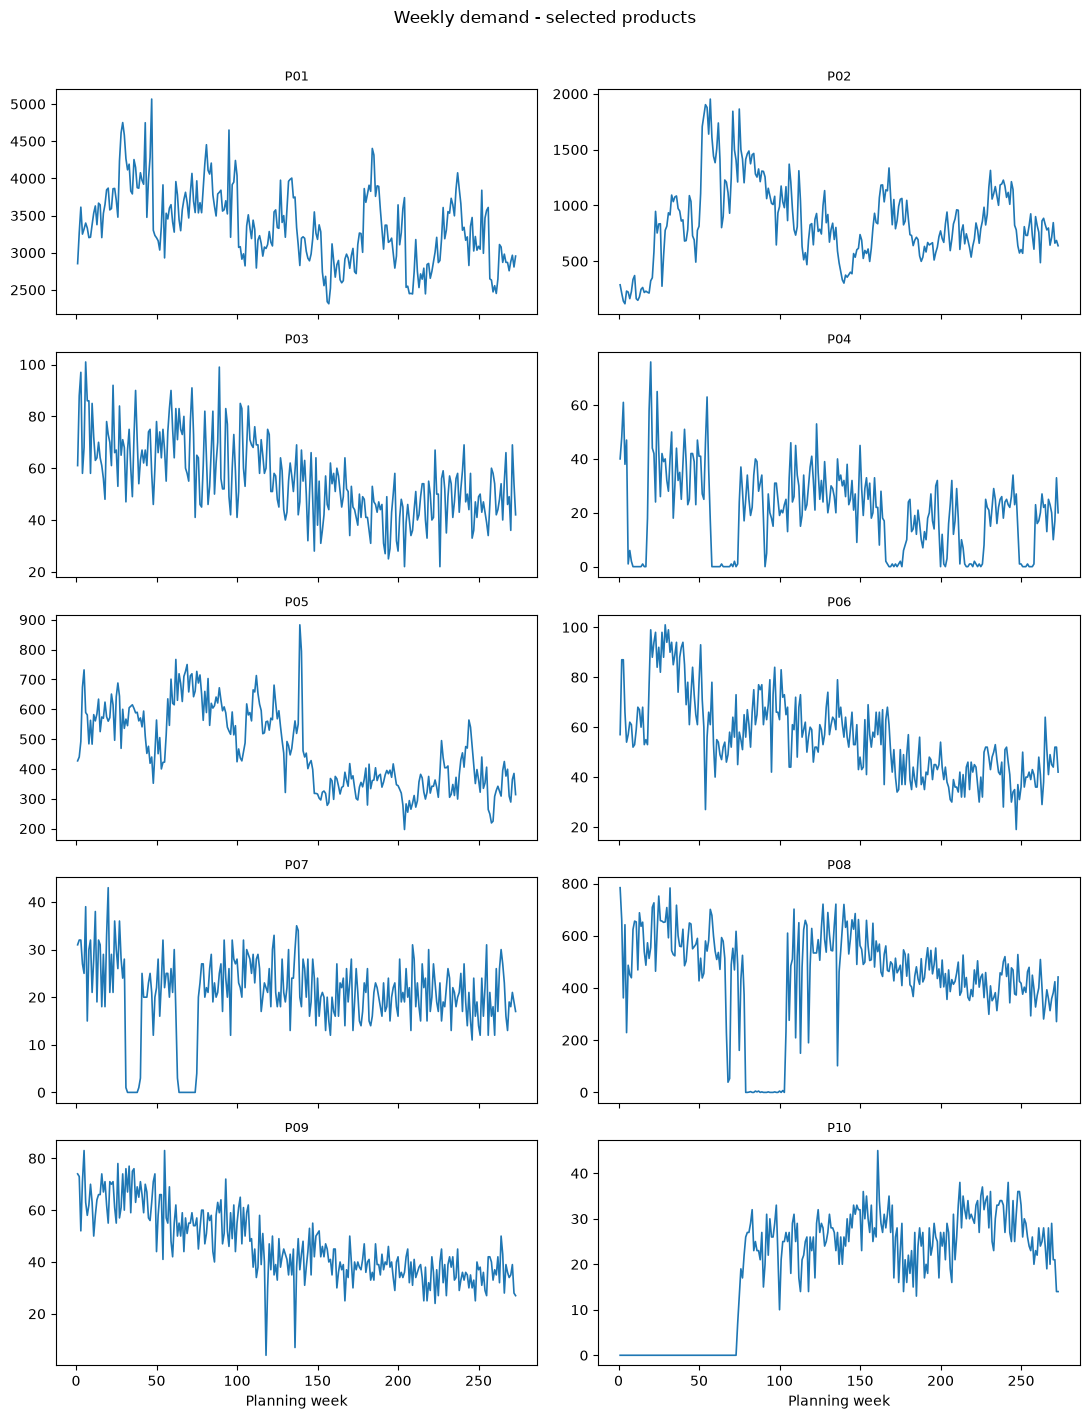

In [78]:
fig, axes = plt.subplots(5, 2, figsize=(11, 14), sharex=True)

for ax, product_id in zip(axes.flat, product_order):
    series = weekly[weekly["product_id"] == product_id]
    ax.plot(series["week"], series["demand"], linewidth=1.2)
    ax.set_title(product_id, fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel("Planning week")

fig.suptitle("Weekly demand - selected products", y=1.01)
fig.tight_layout()
plt.show()

In [79]:
print(weekly[(weekly['product_id']=='P10')&(weekly['demand']>0)]['week'].min())

74


For **P10** we should consider just data after the 74th week, because before it was no demand or it was not sold yet

In [80]:
weekly = weekly[~((weekly['product_id']=='P10')&(weekly['week']<74))]

In [81]:
categories = demand[["product_id", "category"]].drop_duplicates()
weekly = weekly.merge(categories, on="product_id")

In [82]:
weekly = weekly.sort_values(["product_id", "week"])
g = weekly.groupby("product_id")["demand"]

for lag in [1, 2, 4, 8]:
    weekly[f"lag_{lag}"] = g.shift(lag)

weekly["roll_mean_4"] = g.transform(lambda s: s.shift(1).rolling(4).mean())
weekly["roll_std_4"]  = g.transform(lambda s: s.shift(1).rolling(4).std())

week_start_date = demand.groupby("week")["date"].min().rename("week_start_date")
weekly = weekly.merge(week_start_date, on="week", how="left")
weekly["month"] = pd.to_datetime(weekly["week_start_date"]).dt.month

In [83]:
product_dummies = pd.get_dummies(weekly["product_id"], prefix="product")
category_dummies = pd.get_dummies(weekly["category"], prefix="category")

PRODUCT_DUMMY_COLS = list(product_dummies.columns)
CATEGORY_DUMMY_COLS = list(category_dummies.columns)

weekly = pd.concat([weekly, product_dummies, category_dummies], axis=1)

In [84]:
FEATURE_COLS = [
    "lag_1", "lag_2", "lag_4", "lag_8",
    "roll_mean_4", "roll_std_4",
    "month",
] + PRODUCT_DUMMY_COLS + CATEGORY_DUMMY_COLS

max_week = weekly["week"].max()
cutoff = max_week - 12

train = weekly[weekly["week"] <= cutoff].dropna(subset=FEATURE_COLS)
test = weekly[weekly["week"] > cutoff]

assert test[FEATURE_COLS].isna().sum().sum() == 0, "test set has NaN features, check lag history"

X_train, y_train = train[FEATURE_COLS], train["demand"]
X_test, y_test = test[FEATURE_COLS], test["demand"]

print("train rows:", len(X_train), " test rows:", len(X_test))

train rows: 2457  test rows: 120


In [85]:
def evaluate(model):
    y_pred = model.predict(X_test)
    print('RMSE :', root_mean_squared_error(y_test, y_pred))
    print('MAE :', mean_absolute_error(y_test, y_pred))

In [86]:
rf = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)
print("RandomForest")
evaluate(rf)

RandomForest
RMSE : 76.10749582665834
MAE : 39.13101968611129


In [87]:
xgb = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)
print("XGBoost")
evaluate(xgb)

XGBoost
RMSE : 67.9109878540039
MAE : 35.97175598144531


In [88]:
lgbm = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, verbose=-1)
lgbm.fit(X_train, y_train)
print("LightGBM")
evaluate(lgbm)

LightGBM
RMSE : 67.05049877650531
MAE : 35.21173963669864


## Per-product error breakdown

Aggregate MAE/RMSE hides how each model does per product : pooling all 10 products together
lets the high-volume ones (P01 ~3300/week) dominate the metric, so a model could look best
overall while doing poorly on the low-volume products (P04, P07, P09, P10).

In [89]:
models = {"RandomForest": rf, "XGBoost": xgb, "LightGBM": lgbm}

test_results = test[["product_id", "week", "demand"]].copy()
for name, model in models.items():
    test_results[name] = model.predict(X_test)

rows = []
for name in models:
    for product_id, group in test_results.groupby("product_id"):
        rows.append((
            product_id,
            name,
            mean_absolute_error(group["demand"], group[name]),
            root_mean_squared_error(group["demand"], group[name]),
        ))

per_product_errors = pd.DataFrame(rows, columns=["product_id", "model", "MAE", "RMSE"])

mae_table = per_product_errors.pivot(index="product_id", columns="model", values="MAE").round(1)
rmse_table = per_product_errors.pivot(index="product_id", columns="model", values="RMSE").round(1)

print("MAE per product")
display(mae_table)
print("\nRMSE per product")
display(rmse_table)

MAE per product


model,LightGBM,RandomForest,XGBoost
product_id,,,
P01,95.8,132.3,98.4
P02,107.3,114.5,115.8
P03,10.1,9.1,10.3
P04,5.5,4.8,5.3
P05,45.3,43.4,44.3
P06,6.5,7.3,7.1
P07,5.7,4.4,4.3
P08,65.1,65.5,63.6
P09,6.1,6.0,6.3



RMSE per product


model,LightGBM,RandomForest,XGBoost
product_id,,,
P01,122.3,161.3,121.9
P02,142.1,150.3,148.1
P03,11.8,10.8,12.1
P04,6.9,6.1,7.0
P05,50.2,47.4,48.3
P06,9.3,10.0,9.4
P07,6.4,5.1,5.0
P08,83.0,82.0,81.2
P09,7.4,7.4,7.7


Raw MAE/RMSE aren't comparable across products of very different scale (P01 ~3300/week vs P10
~19/week). Normalize by each product's mean demand **over its full history** (not just the
12-week test window, which is a small and potentially atypical slice) to get a relative error
that's actually comparable product to product.

In [90]:
mean_demand_by_product = weekly.groupby("product_id")["demand"].mean()

mae_table_norm = mae_table.div(mean_demand_by_product, axis=0).mul(100).round(1)
rmse_table_norm = rmse_table.div(mean_demand_by_product, axis=0).mul(100).round(1)

print("MAE as % of mean demand per product")
display(mae_table_norm)
print("RMSE as % of mean demand per product")
display(rmse_table_norm)

MAE as % of mean demand per product


model,LightGBM,RandomForest,XGBoost
product_id,,,
P01,2.8,3.9,2.9
P02,12.5,13.3,13.5
P03,17.9,16.2,18.3
P04,26.9,23.5,25.9
P05,9.7,9.3,9.5
P06,11.6,13.0,12.7
P07,27.8,21.4,21.0
P08,14.5,14.6,14.2
P09,13.1,12.9,13.5


RMSE as % of mean demand per product


model,LightGBM,RandomForest,XGBoost
product_id,,,
P01,3.6,4.8,3.6
P02,16.6,17.5,17.3
P03,21.0,19.2,21.5
P04,33.7,29.8,34.2
P05,10.7,10.1,10.3
P06,16.6,17.8,16.8
P07,31.2,24.9,24.4
P08,18.5,18.3,18.1
P09,15.9,15.9,16.5


## True vs predicted demand on the test set, per product

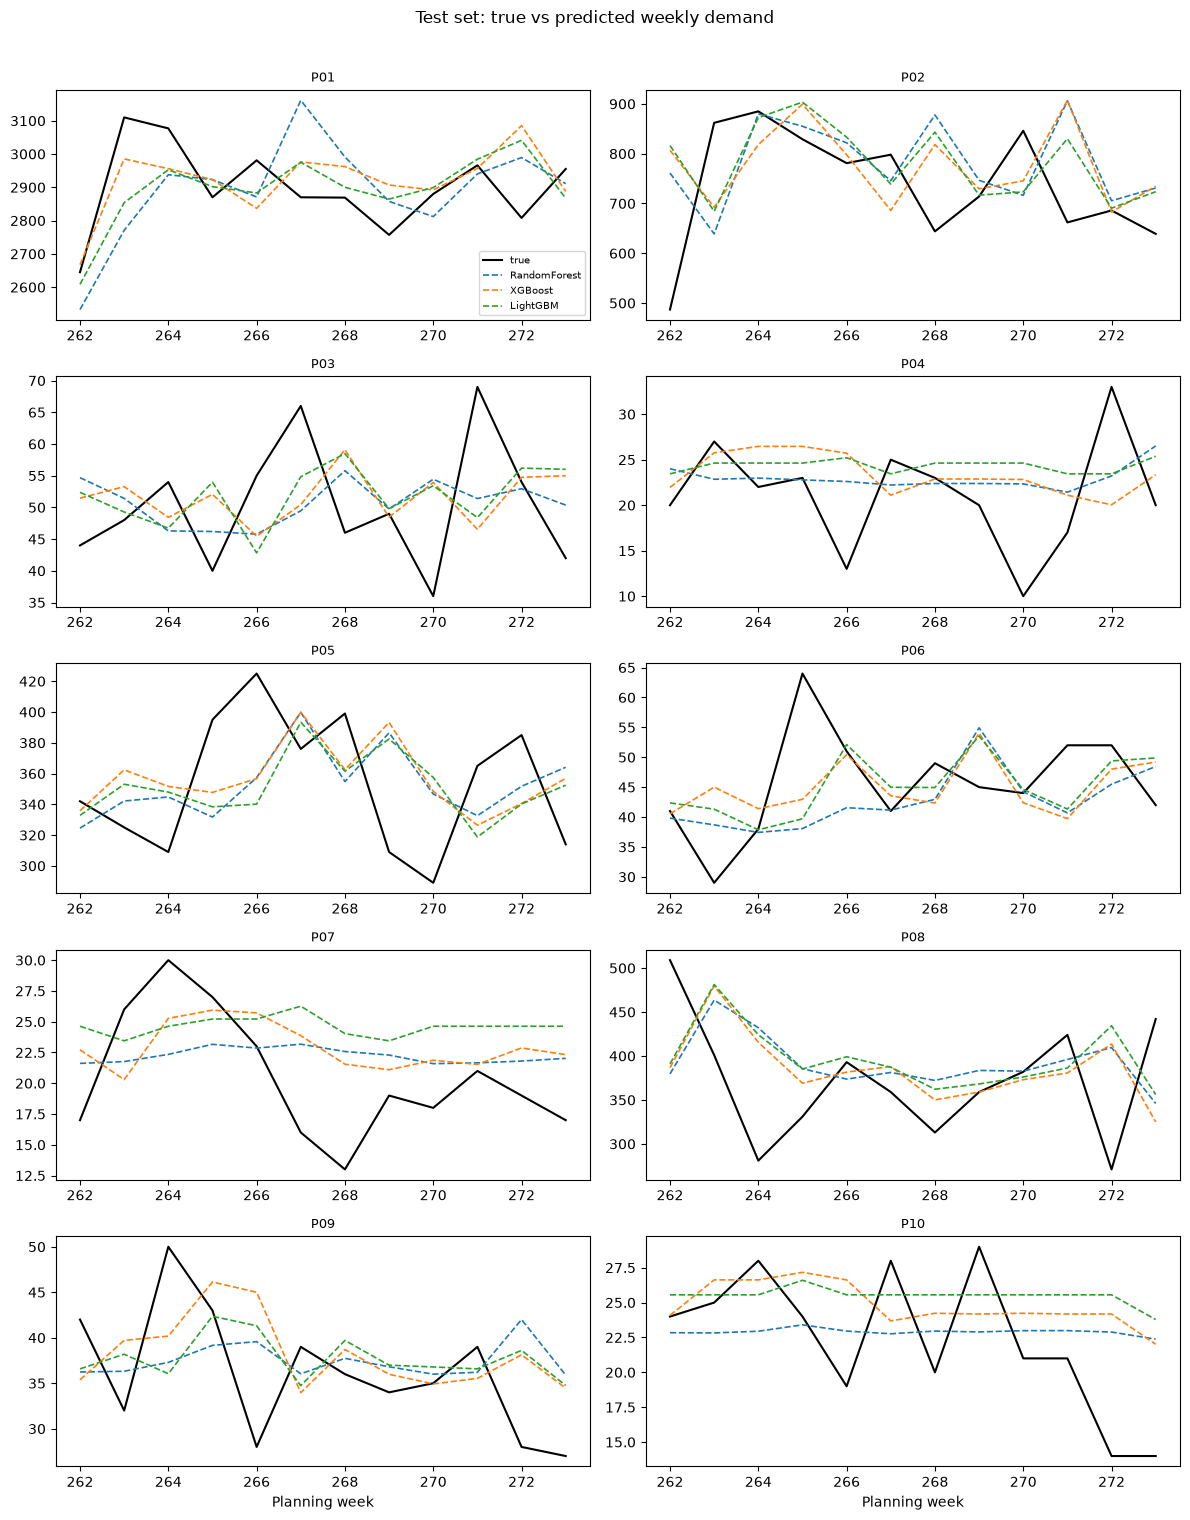

In [91]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15), sharex=False)

for ax, product_id in zip(axes.flat, product_order):
    series = test_results[test_results["product_id"] == product_id].sort_values("week")
    ax.plot(series["week"], series["demand"], label="true", color="black", linewidth=1.5)
    for name in models:
        ax.plot(series["week"], series[name], label=name, linewidth=1.2, linestyle="--")
    ax.set_title(product_id, fontsize=9)

axes.flat[0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("Planning week")

fig.suptitle("Test set: true vs predicted weekly demand", y=1.01)
fig.tight_layout()
plt.show()

## Per-product model selection

Pick whichever model had the lowest MAE for each product individually, rather than a single
global winner. Note this ranking is identical whether you use raw or normalized MAE -- dividing
every model's error for one product by that same product's mean demand doesn't change which
model was smallest, it only makes different *products* comparable to each other.

In [92]:
best_model = mae_table.idxmin(axis=1)
best_model

product_id
P01        LightGBM
P02        LightGBM
P03    RandomForest
P04    RandomForest
P05    RandomForest
P06        LightGBM
P07         XGBoost
P08         XGBoost
P09    RandomForest
P10    RandomForest
dtype: str

## Refit on full history

The models above were trained on data up to `cutoff` (holding out the last 12 weeks for
evaluation). For the actual production forecast we want every available week, including that
held-out window, so refit each model type on the full feature-complete dataset before
forecasting forward.

In [93]:
full = weekly.dropna(subset=FEATURE_COLS)
X_full, y_full = full[FEATURE_COLS], full["demand"]

final_models = {
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42, verbose=-1),
}

for name, model in final_models.items():
    model.fit(X_full, y_full)

print("refit on", len(X_full), "rows")

refit on 2577 rows


## 12-week-ahead forecast (recursive)

Weeks beyond week 273 don't have real lag values yet, so each product's forecast is built
step by step: predict week 274, append that prediction to its demand history, use it (alongside
the real history) to build the lag/rolling features for week 275, and so on. `month` for future
weeks is extrapolated by adding 7 days per step from the last known week's start date -- no real
calendar data exists that far out.

In [94]:
FORECAST_HORIZON = 12
last_week = weekly["week"].max()
last_date = pd.to_datetime(weekly["week_start_date"]).max()

forecast_rows = []

for pid in product_order:
    prod_hist = weekly[weekly["product_id"] == pid].sort_values("week")
    demand_history = prod_hist["demand"].tolist()
    dummy_row = prod_hist[PRODUCT_DUMMY_COLS + CATEGORY_DUMMY_COLS].iloc[0]
    model = final_models[best_model[pid]]

    for step in range(1, FORECAST_HORIZON + 1):
        target_week = last_week + step
        target_date = last_date + pd.Timedelta(weeks=step)

        features = pd.DataFrame([{
            "lag_1": demand_history[-1],
            "lag_2": demand_history[-2],
            "lag_4": demand_history[-4],
            "lag_8": demand_history[-8],
            "roll_mean_4": np.mean(demand_history[-4:]),
            "roll_std_4": np.std(demand_history[-4:], ddof=1),
            "month": target_date.month,
            **dummy_row.to_dict(),
        }])[FEATURE_COLS]

        pred = max(model.predict(features)[0], 0)  # demand can't go negative
        demand_history.append(pred)
        forecast_rows.append((pid, target_week, pred))

forecast = pd.DataFrame(forecast_rows, columns=["product_id", "week", "forecast"])
forecast.head(15)

,product_id,week,forecast
0,P01,274,3024.383803
1,P01,275,3126.768559
2,P01,276,3114.053281
3,P01,277,3117.200095
4,P01,278,3163.400499
5,P01,279,3163.400499
6,P01,280,3314.386566
7,P01,281,3408.876703
8,P01,282,3405.527763
9,P01,283,3405.989109


## Uncertainty bounds

Grounded in the actual backtest residuals of each product's *chosen* model (not an arbitrary
±20%). `Z = 1.28` gives roughly an 80% interval under a normal-residual assumption. Lower bound
is clipped at 0 since demand can't be negative.

In [95]:
Z = 1.28

resid_std = {}
for pid in product_order:
    model_name = best_model[pid]
    sub = test_results[test_results["product_id"] == pid]
    resid_std[pid] = (sub["demand"] - sub[model_name]).std()

forecast["model"] = forecast["product_id"].map(best_model)
forecast["resid_std"] = forecast["product_id"].map(resid_std)
forecast["lower_bound"] = (forecast["forecast"] - Z * forecast["resid_std"]).clip(lower=0).round(1)
forecast["upper_bound"] = (forecast["forecast"] + Z * forecast["resid_std"]).round(1)
forecast["forecast"] = forecast["forecast"].round(1)

forecast = forecast[["week", "product_id", "forecast", "lower_bound", "upper_bound", "model"]]
forecast.head(15)

,week,product_id,forecast,lower_bound,upper_bound,model
0,274,P01,3024.4,2861.0,3187.8,LightGBM
1,275,P01,3126.8,2963.3,3290.2,LightGBM
2,276,P01,3114.1,2950.6,3277.5,LightGBM
3,277,P01,3117.2,2953.8,3280.6,LightGBM
4,278,P01,3163.4,3000.0,3326.8,LightGBM
5,279,P01,3163.4,3000.0,3326.8,LightGBM
6,280,P01,3314.4,3151.0,3477.8,LightGBM
7,281,P01,3408.9,3245.5,3572.3,LightGBM
8,282,P01,3405.5,3242.1,3568.9,LightGBM
9,283,P01,3406.0,3242.6,3569.4,LightGBM


## Save the forecast

In [96]:
from pathlib import Path

output_dir = Path("../data/processed/forecasts")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "forecast.csv"
forecast.to_csv(output_path, index=False)
print("Saved:", output_path.resolve())
print("Shape:", forecast.shape)

Saved: C:\Users\HP\Walid\Industrial_production_optimization\data\processed\forecasts\forecast.csv
Shape: (120, 6)


## Visual check: last 52 weeks of history + 12-week forecast

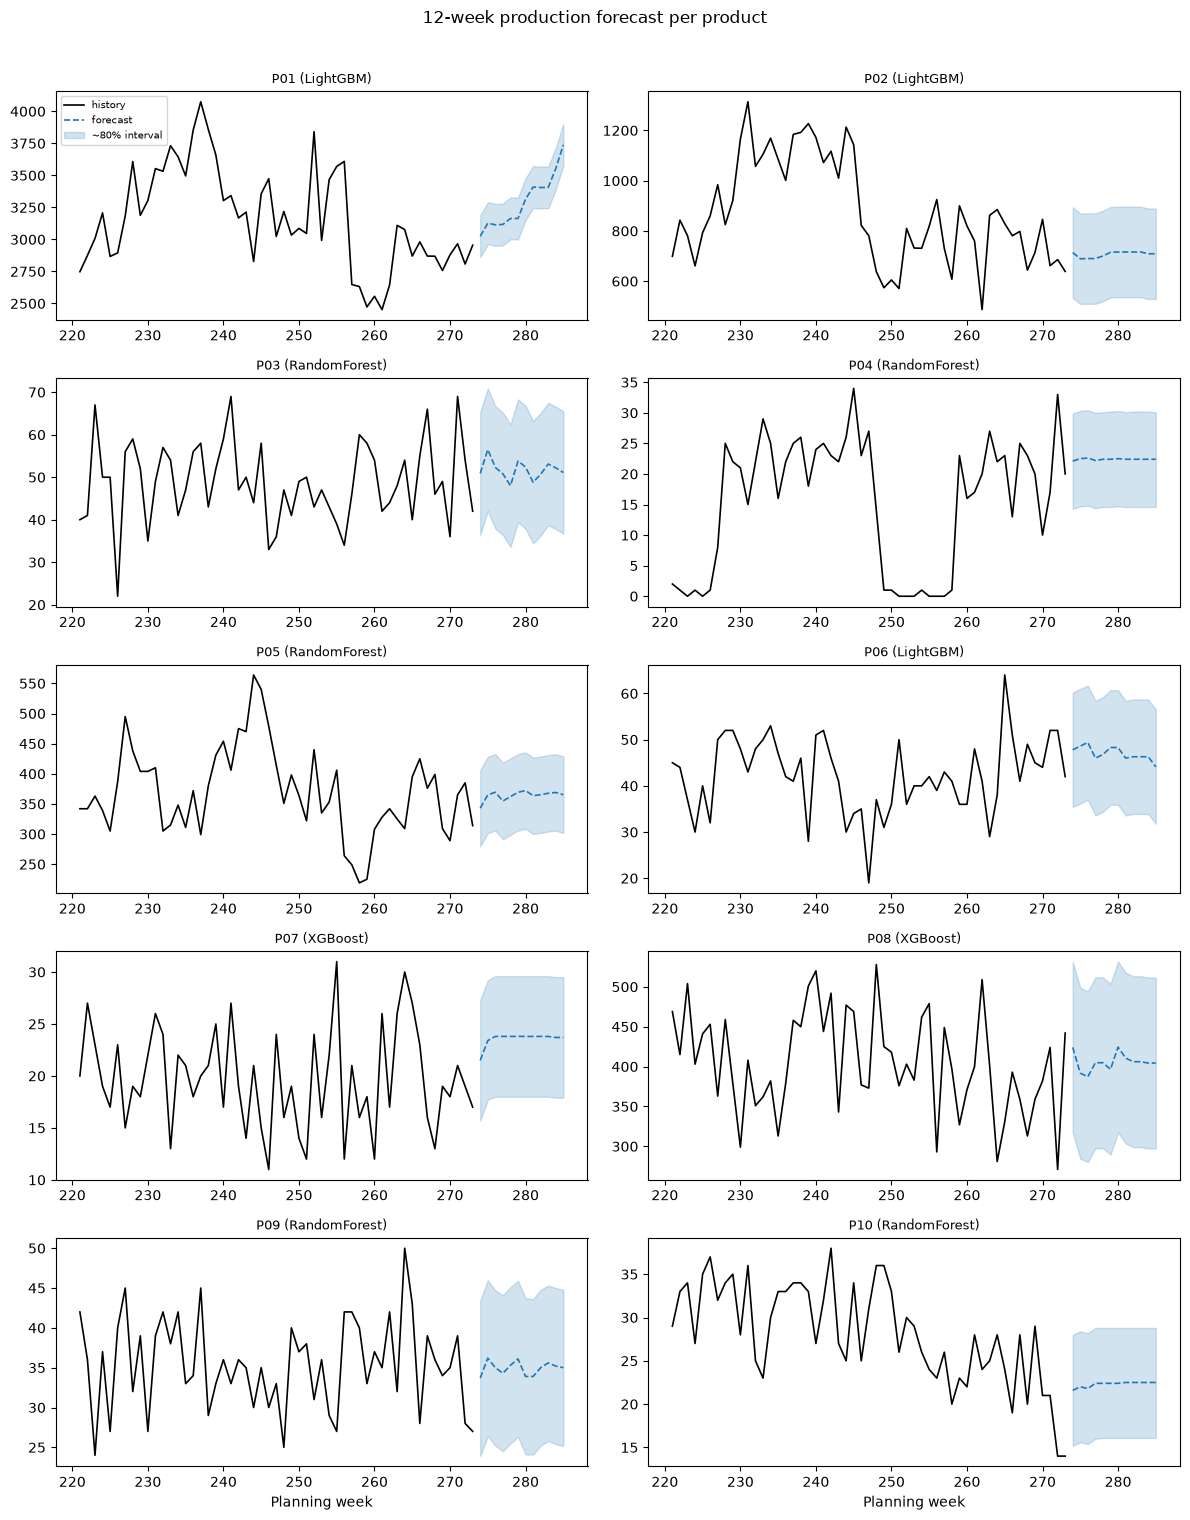

In [97]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15), sharex=False)

for ax, pid in zip(axes.flat, product_order):
    hist = weekly[weekly["product_id"] == pid].sort_values("week")
    hist = hist[hist["week"] >= hist["week"].max() - 52]
    fc = forecast[forecast["product_id"] == pid].sort_values("week")

    ax.plot(hist["week"], hist["demand"], color="black", linewidth=1.2, label="history")
    ax.plot(fc["week"], fc["forecast"], color="tab:blue", linewidth=1.2, linestyle="--", label="forecast")
    ax.fill_between(fc["week"], fc["lower_bound"], fc["upper_bound"], color="tab:blue", alpha=0.2, label="~80% interval")
    ax.set_title(f"{pid} ({best_model[pid]})", fontsize=9)

axes.flat[0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("Planning week")

fig.suptitle("12-week production forecast per product", y=1.01)
fig.tight_layout()
plt.show()